# trace分离链表块划分分析

拆分结果
- <= 64
- 128
- 256
- 512
- 1k-2k
- 4k
- 8k
- \>8k

其余的块全都可以归到这些类中

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ===================== 全局配置（纯英文）=====================
plt.rcParams['font.family'] = 'DejaVu Sans'  # Linux默认自带，无中文警告
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

# ===================== 细分1024以上块 =====================
# 32位系统对齐规则：8字节对齐 + 8字节头尾
SEG_RANGES = [
    (0, 16, "16B"),
    (17, 32, "17-32B"),
    (33, 64, "33-64B"),
    (65, 128, "65-128B"),
    (129, 256, "129-256B"),
    (257, 512, "257-512B"),
    (513, 1024, "512-1K"),
    # 👇 重点：超大块精细拆分（解决之前图表压扁问题）
    (1025, 2048, "1K-2K"),
    (2049, 4096, "2K-4K"),
    (4097, 8192, "4K-8K"),
    (8193, 16384, "8K-16K"),
    (16385, float('inf'), ">16K")
]

In [6]:
# ===================== 解析trace文件 =====================
def parse_trace(trace_path):
    block_sizes = []
    HEADER_FOOTER = 8
    ALIGN = 8

    with open(trace_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # 跳过前4行头部
    for line in lines[4:]:
        line = line.strip()
        if not line: continue
        parts = line.split()
        
        # 只处理 a(malloc) / r(realloc)
        if parts[0] == 'a' or parts[0] == 'r':
            raw = int(parts[2])
        else:
            continue
        
        # 计算真实块大小
        real = raw + HEADER_FOOTER
        aligned = ((real + ALIGN - 1) // ALIGN) * ALIGN
        block_sizes.append(aligned)
    
    # 分类统计
    count = {}
    for s, e, name in SEG_RANGES:
        count[name] = sum(1 for x in block_sizes if s <= x <= e)
    
    return {
        "file": os.path.basename(trace_path),
        "total": len(block_sizes),
        "dist": count
    }

# ===================== 绘图（高颜值+无警告）=====================
def plot_result(data):
    print("="*60)
    print(f"Trace: {data['file']} | Total Ops: {data['total']}")
    print("="*60)
    
    labels = list(data['dist'].keys())
    values = list(data['dist'].values())
    colors = sns.color_palette("coolwarm", len(labels))

    fig, (ax1, ax2) = plt.subplots(1, 2)
    
    # 左图：柱状图
    bars = ax1.bar(labels, values, color=colors)
    ax1.set_title('Block Size Distribution', fontsize=14, weight='bold')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    # 标注数值
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax1.text(bar.get_x()+bar.get_width()/2, h, f'{int(h)}',
                    ha='center', va='bottom', fontsize=9)

    # 右图：饼图
    non_zero = [(i, v) for i, v in enumerate(values) if v > 0]
    if non_zero:
        idx, val = zip(*non_zero)
        lab = [labels[i] for i in idx]
        ax2.pie(val, labels=lab, autopct='%1.1f%%', 
               colors=[colors[i] for i in idx], startangle=90)
    ax2.set_title('Percentage', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.show()
    print("\n")

Trace: trace0.rep | Total Ops: 2847


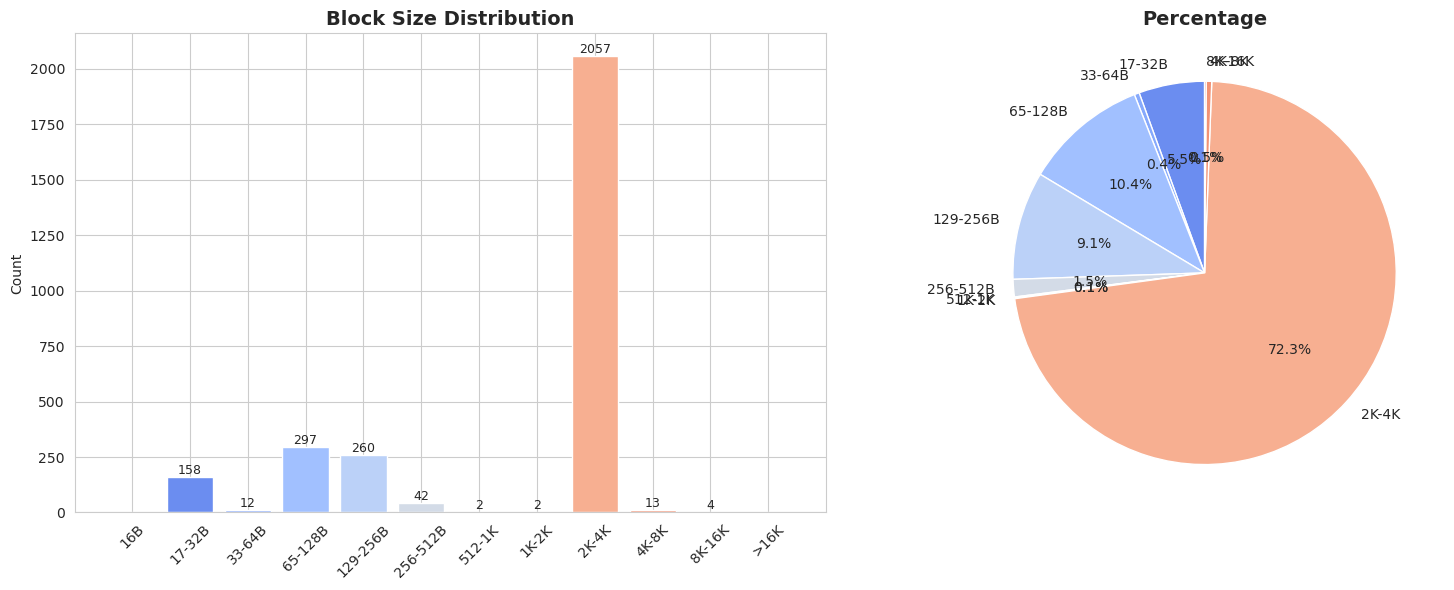

In [ ]:
# ===================== 分析 trace 文件 =====================
trace_path = "./trace0.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace1.rep | Total Ops: 2924


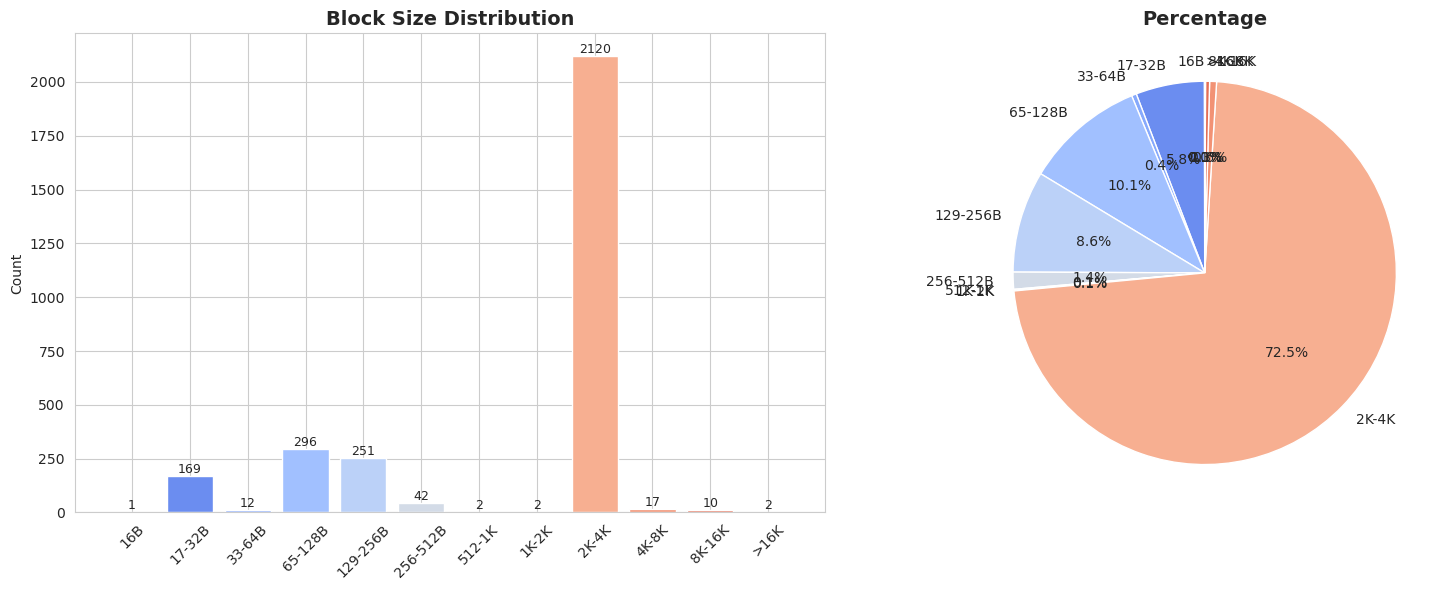

In [8]:
trace_path = "./trace1.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace2.rep | Total Ops: 3324


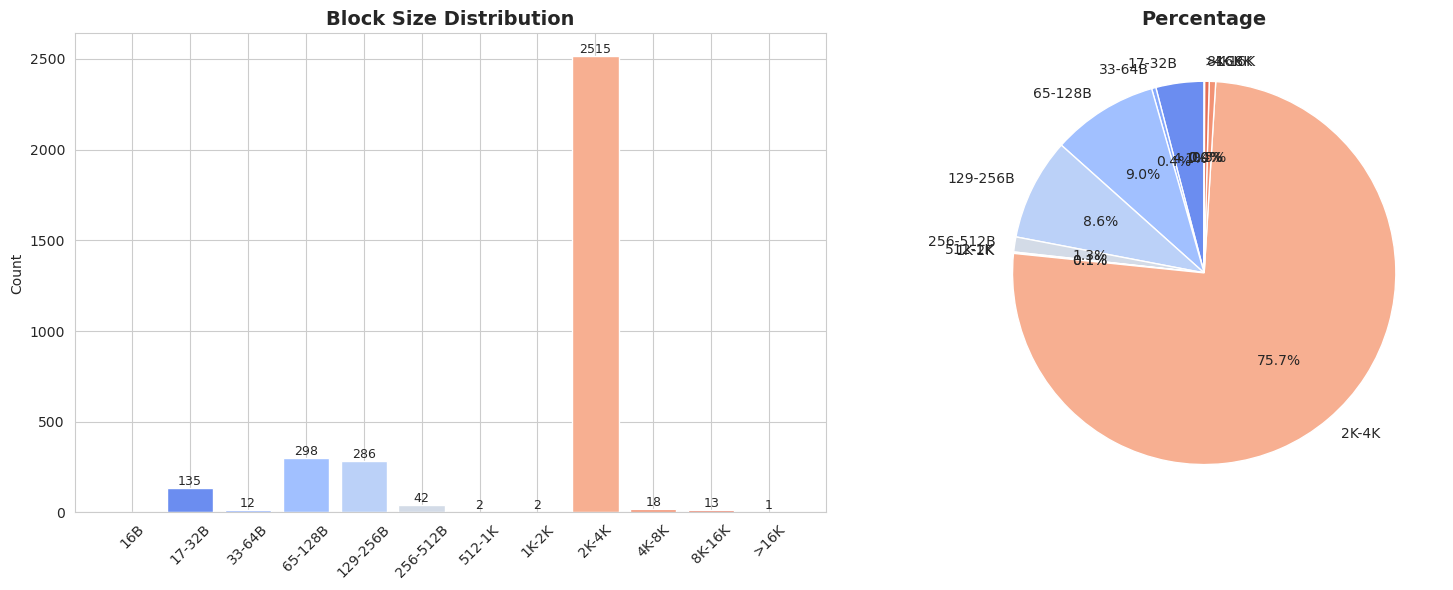

In [9]:
trace_path = "./trace2.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace3.rep | Total Ops: 2690


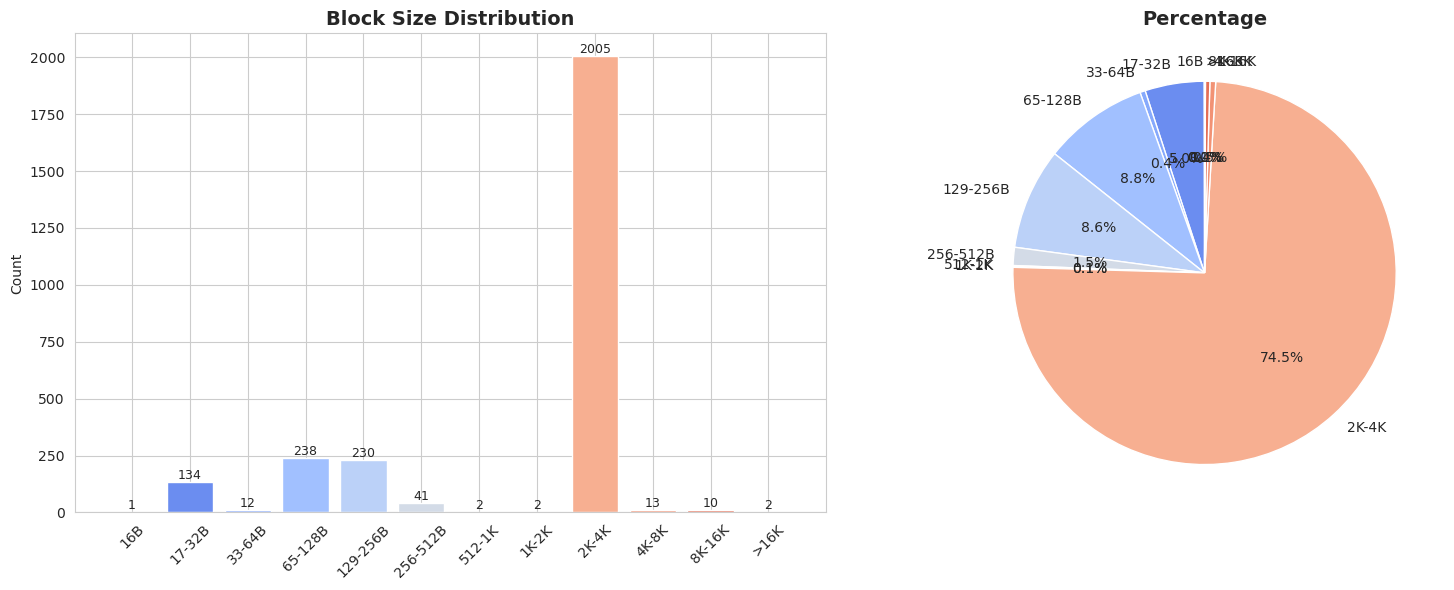

In [10]:
trace_path = "./trace3.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace4.rep | Total Ops: 7200


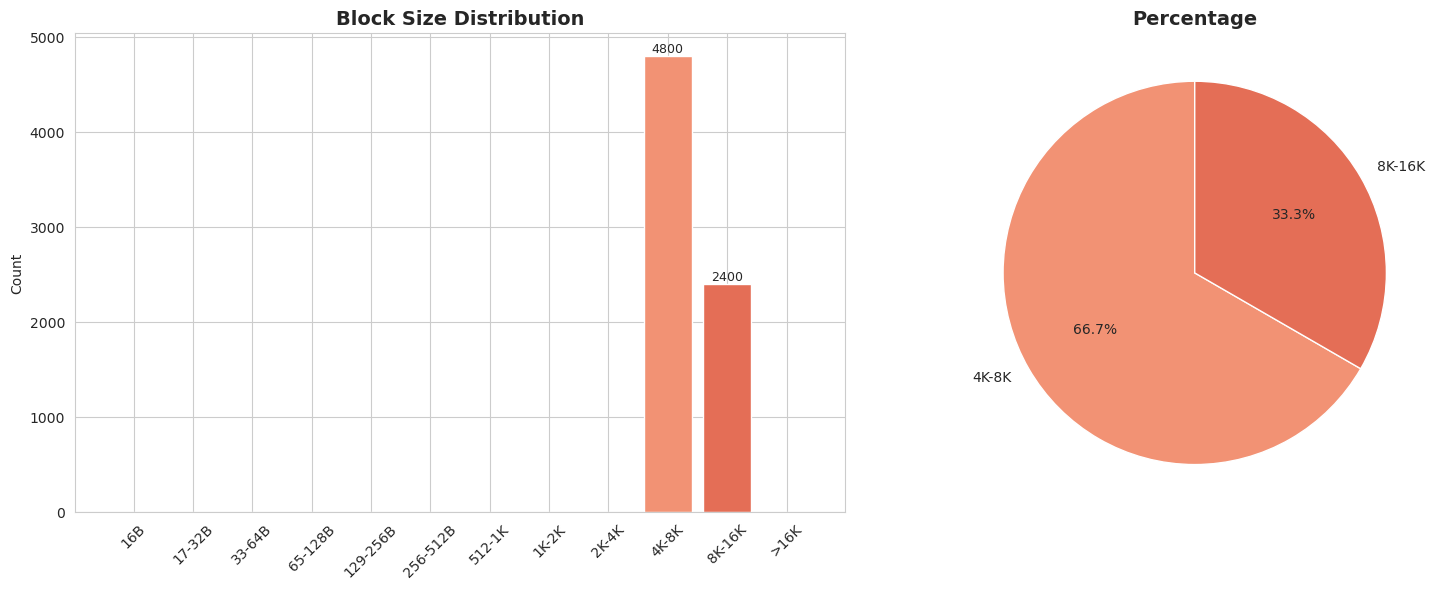

In [11]:
trace_path = "./trace4.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace5.rep | Total Ops: 2400


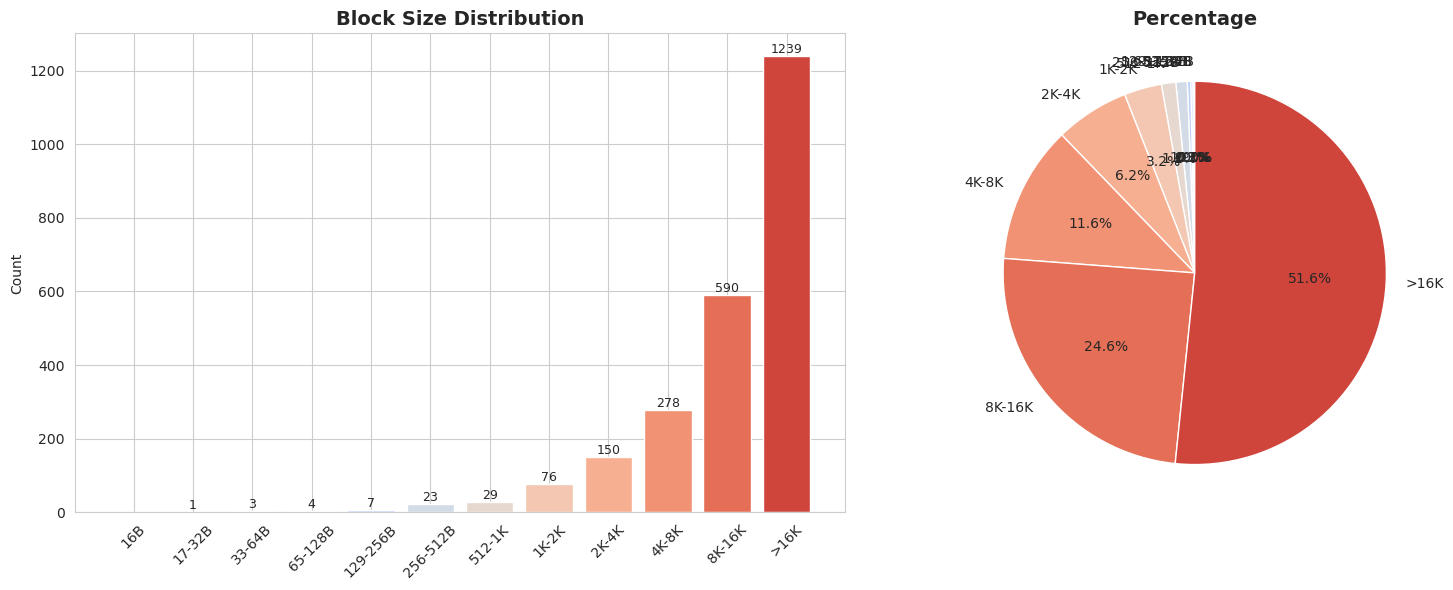

In [12]:
trace_path = "./trace5.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace6.rep | Total Ops: 2400


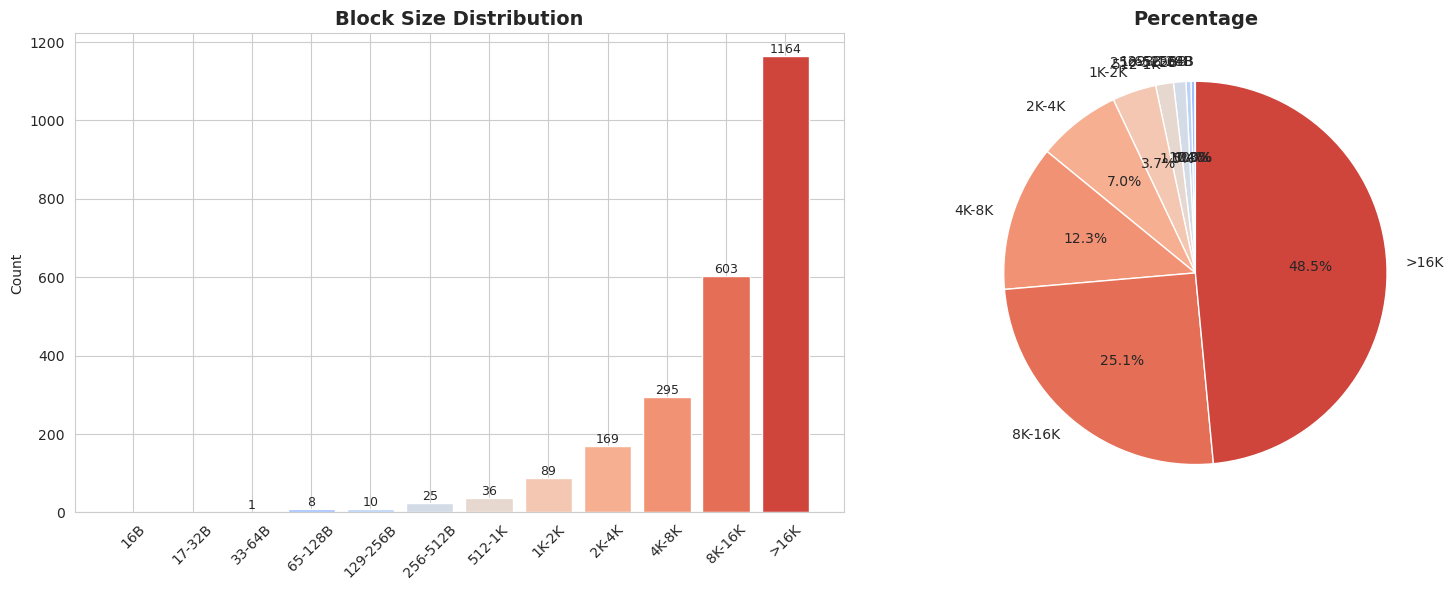

In [13]:
trace_path = "./trace6.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace7.rep | Total Ops: 6000


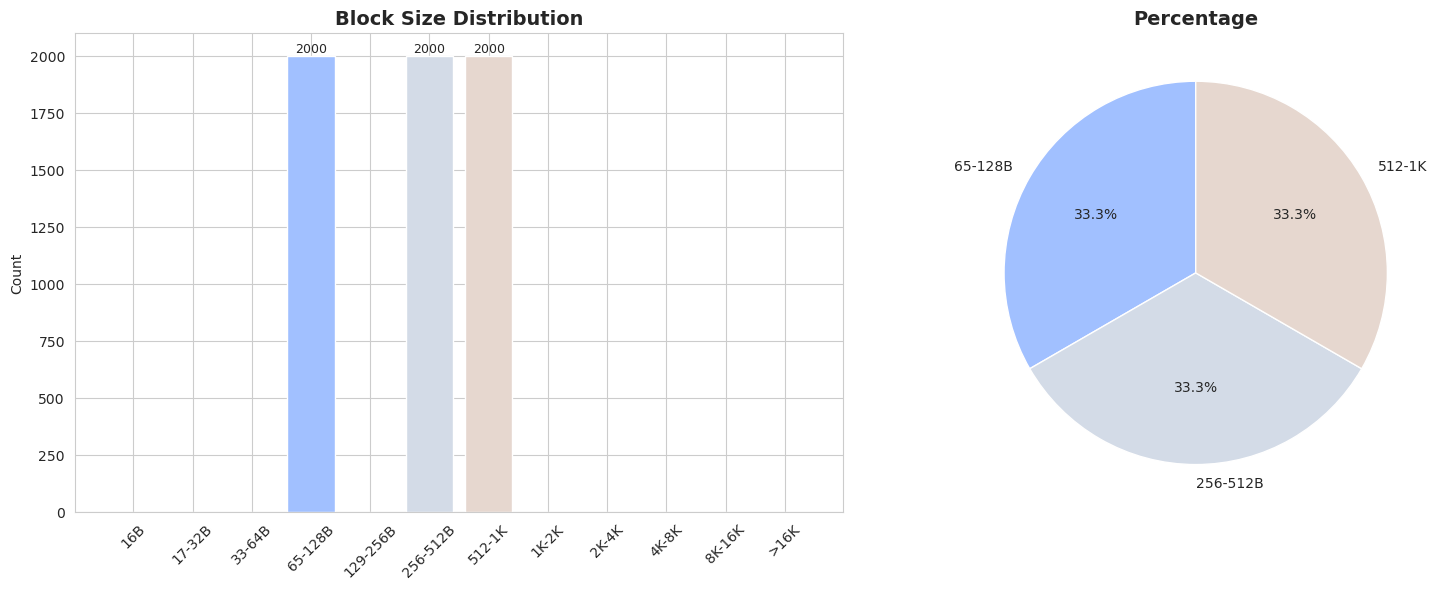

In [14]:
trace_path = "./trace7.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace8.rep | Total Ops: 12000


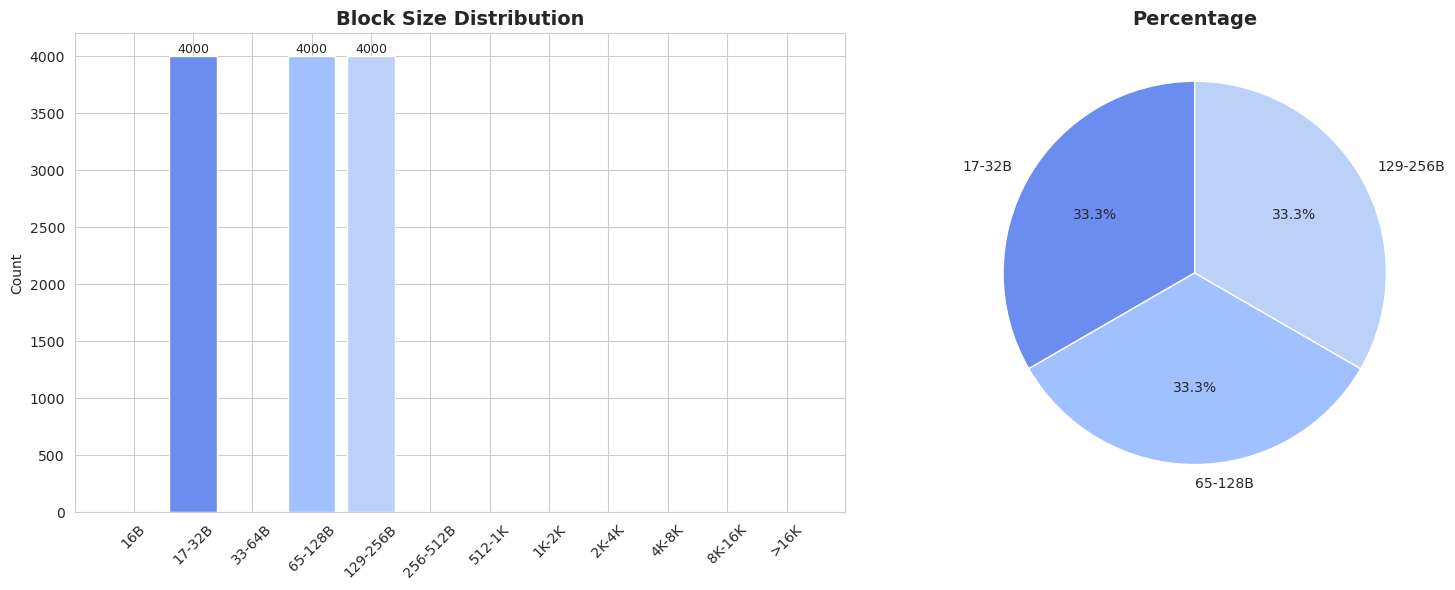

In [15]:
trace_path = "./trace8.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace9.rep | Total Ops: 9600


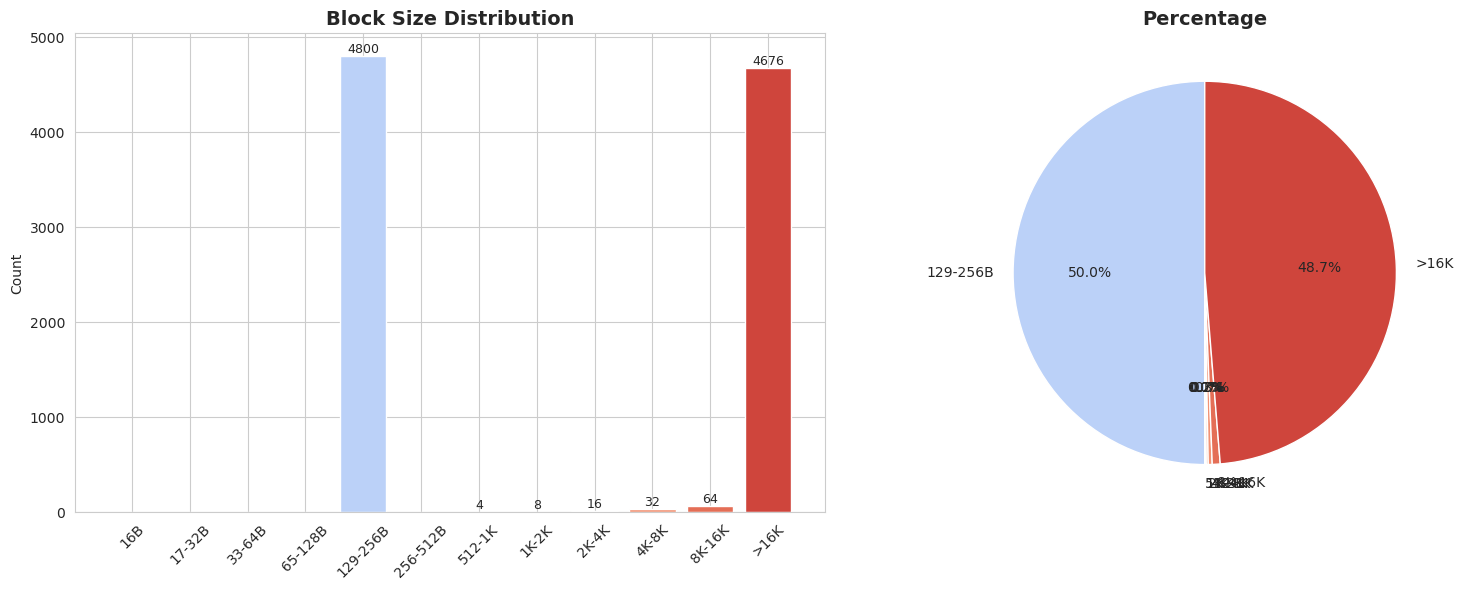

In [16]:
trace_path = "./trace9.rep"
data = parse_trace(trace_path)
plot_result(data)

Trace: trace10.rep | Total Ops: 9600


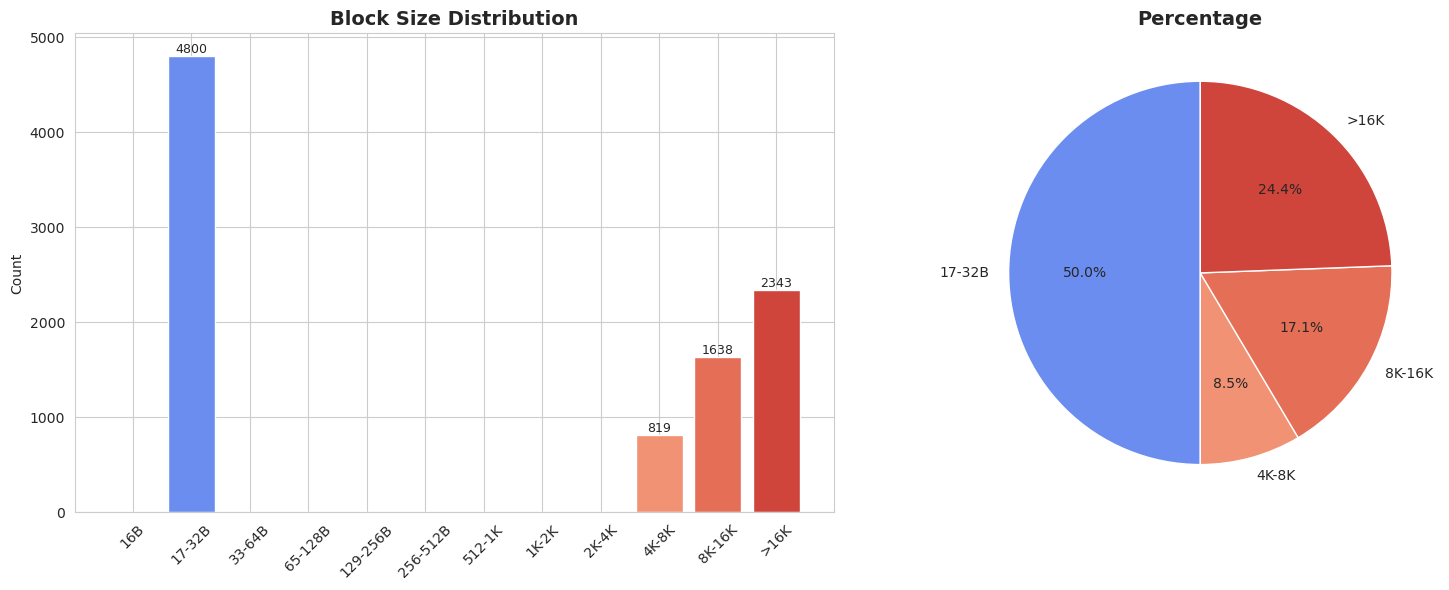

In [17]:
trace_path = "./trace10.rep"
data = parse_trace(trace_path)
plot_result(data)